In [1]:
import pandas as pd
import json
import numpy as np
from google.colab import files

In [3]:
with open('sensor_data.json', 'r') as f:
    data_dict = json.load(f)

In [10]:
# --- 2. Flatten the Data ---
# Convert dictionary of dictionaries into a list of single-row dictionaries
data_list = list(data_dict.values())
real_df = pd.json_normalize(data_list)

In [11]:
# Select relevant columns
features = [
    'pzem.voltage',
    'ina3221.battery.voltage',
    'ina3221.battery.current_ma',
    'system.rssi',
    'system.free_heap',
    'system.cpu_temp',
    'si7021.temperature'
]
real_df = real_df[features]

In [13]:
# --- 2. Synthetic Data Configuration ---
n_rows = 1000  # Number of rows per scenario

# --- Helper Function for Independent Variables ---
# These are generated identically for both scenarios to remove correlation
def generate_system_noise(n):
    return {
        'system.rssi': np.round(np.random.normal(-78, 4, n), 4),
        'system.free_heap': np.round(np.random.normal(194056, 10, n), 4),
        'system.cpu_temp': np.round(np.random.normal(43.6, 0.5, n), 4),
        'si7021.temperature': np.round(np.random.normal(31.7, 0.5, n), 4)
    }

# --- SCENARIO A: MAINS ON (Healthy & Charging) ---
common_noise_on = generate_system_noise(n_rows)
mains_on = {
    'pzem.voltage': np.round(np.random.normal(218.0, 2.0, n_rows), 4),
    'ina3221.battery.voltage': np.round(np.random.uniform(8.0, 8.104, n_rows), 4),
    'ina3221.battery.current_ma': np.round(np.random.uniform(-240.0, -230.0, n_rows), 4),
    **common_noise_on
}

# --- SCENARIO B: MAINS OFF (Healthy Discharging) ---
# FIX: PZEM voltage now generates uniform random noise between 0.0V and 15.0V
common_noise_off = generate_system_noise(n_rows)
mains_off = {
    'pzem.voltage': np.round(np.random.uniform(0.0, 15.0, n_rows), 4), # Valid noise (0-15V)
    'ina3221.battery.voltage': np.round(np.random.uniform(6.6, 8.0, n_rows), 4),
    'ina3221.battery.current_ma': np.round(np.random.normal(190.0, 10.0, n_rows), 4),
    **common_noise_off
}

# Convert to DataFrames
df_on = pd.DataFrame(mains_on)
df_off = pd.DataFrame(mains_off)

# --- 3. Combine & Export ---
# Stack Real + Synthetic ON + Synthetic OFF
final_df = pd.concat([real_df, df_on, df_off], ignore_index=True)

# Shuffle
final_df = final_df.sample(frac=1).reset_index(drop=True)

# Final Rounding Sweep
final_df = final_df.round(4)

print(f"Total Data Points: {len(final_df)}")
print("Preview of Data:")
print(final_df.head())

# Save
filename = 'sensor_health_training_data_final.csv'
final_df.to_csv(filename, index=False)
files.download(filename)

Total Data Points: 8475
Preview of Data:
   pzem.voltage  ina3221.battery.voltage  ina3221.battery.current_ma  \
0      219.3000                   8.2800                      1.2000   
1      220.3577                   8.0409                   -231.9845   
2        0.0406                   7.7892                    204.9875   
3      220.9760                   8.0346                   -233.1911   
4        9.7005                   7.4100                    224.6765   

   system.rssi  system.free_heap  system.cpu_temp  si7021.temperature  
0     -82.0000       193676.0000          42.6000             31.6792  
1     -86.0093       194055.5083          42.3434             31.5185  
2     -75.0782       194043.1006          43.9677             31.8966  
3     -75.8872       194045.6319          43.6697             32.6070  
4     -81.9430       194061.8837          43.3912             31.6517  


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

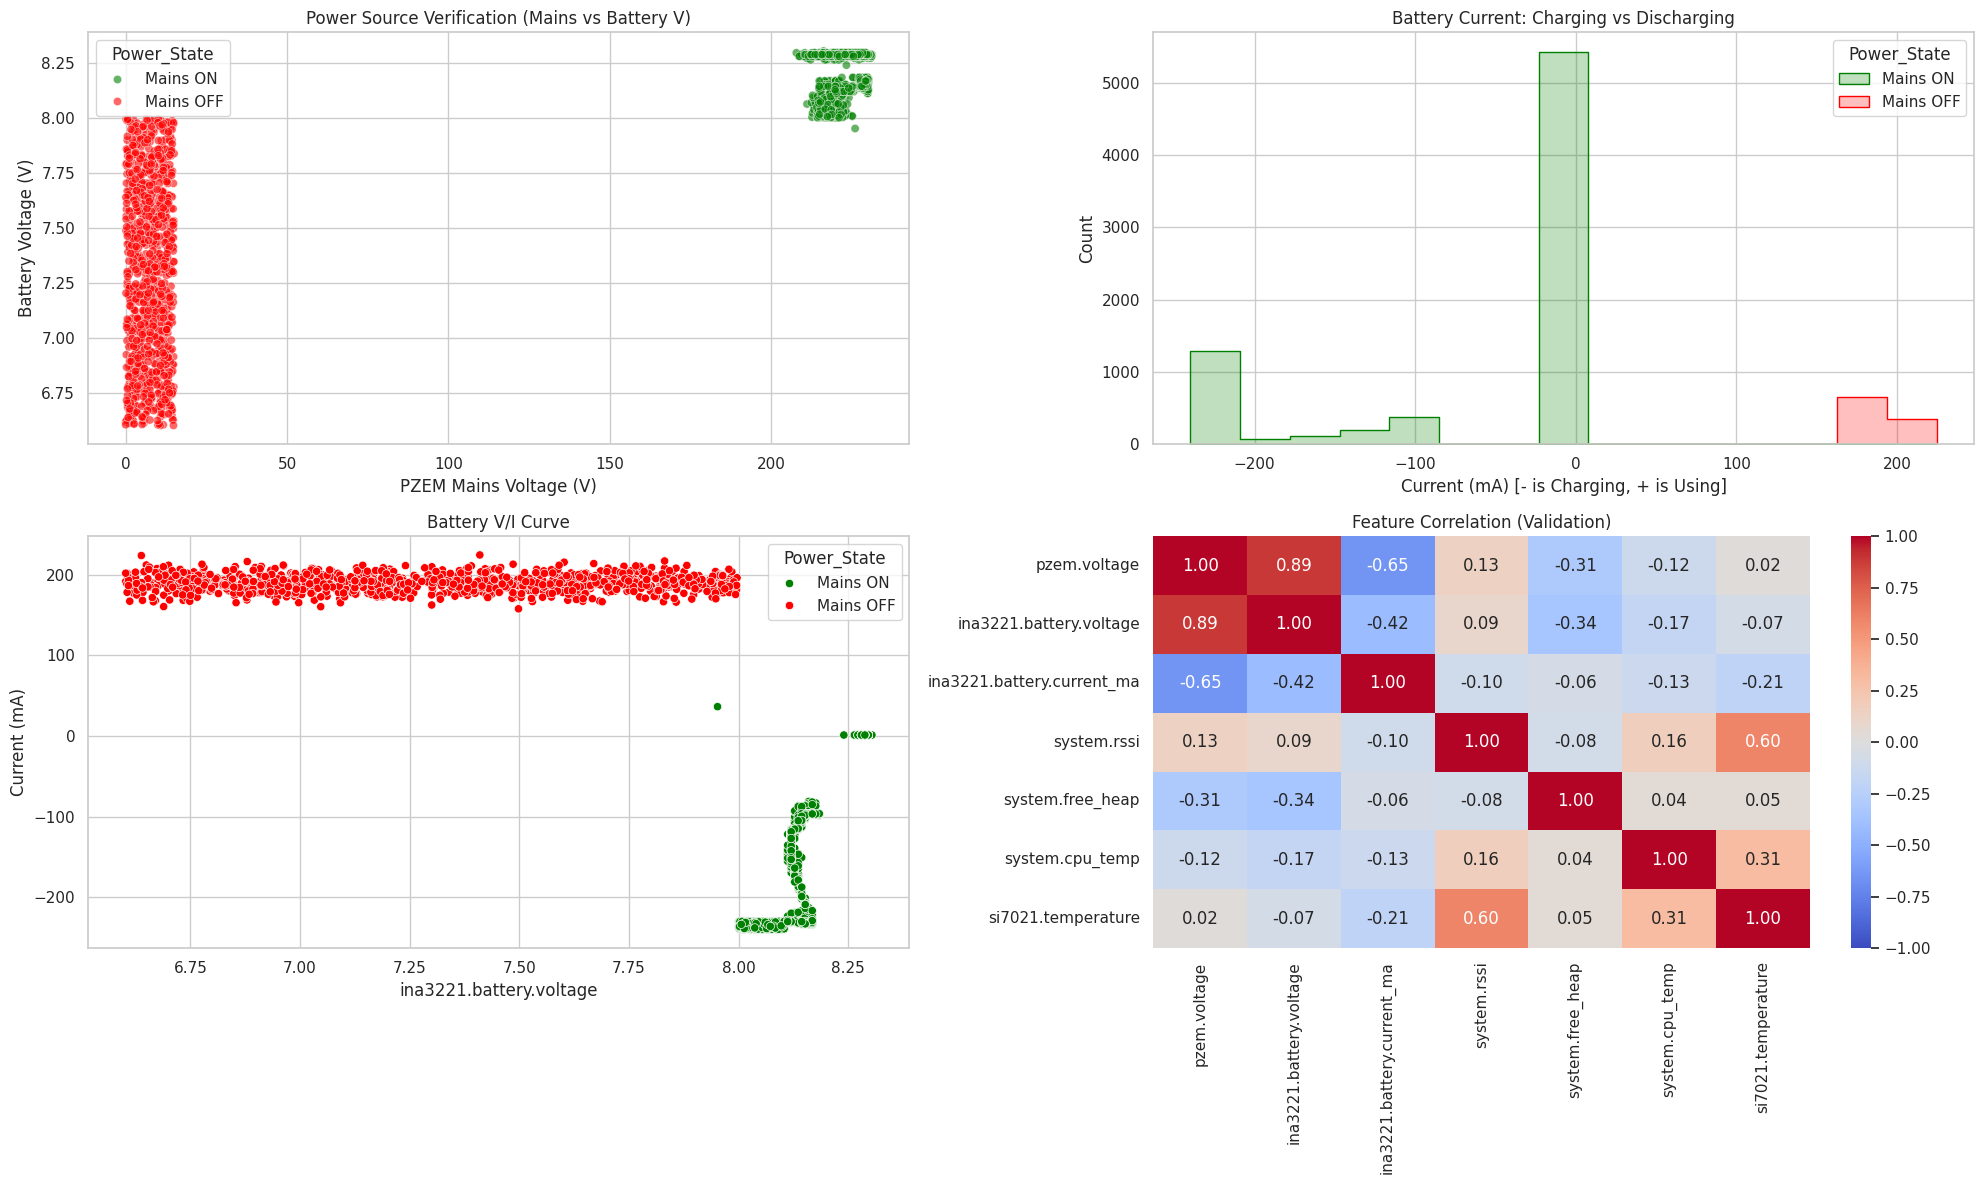

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Data
filename = 'sensor_health_training_data_final.csv'
try:
    df = pd.read_csv(filename)
except FileNotFoundError:
    print(f"Error: Please make sure '{filename}' is uploaded or generated.")

# 2. Create a "State" column just for coloring the graphs (Visualization purpose only)
# We assume if PZEM > 50V, Mains is ON.
df['Power_State'] = df['pzem.voltage'].apply(lambda x: 'Mains ON' if x > 50 else 'Mains OFF')

# --- PLOTTING ---
plt.figure(figsize=(20, 12))
sns.set(style="whitegrid")

# Chart 1: The "Two States" of Power
# This verifies that when Mains is OFF (0-15V), Battery varies widely (6.6-8.0V)
plt.subplot(2, 2, 1)
sns.scatterplot(
    data=df,
    x='pzem.voltage',
    y='ina3221.battery.voltage',
    hue='Power_State',
    palette={'Mains ON': 'green', 'Mains OFF': 'red'},
    alpha=0.6
)
plt.title('Power Source Verification (Mains vs Battery V)')
plt.xlabel('PZEM Mains Voltage (V)')
plt.ylabel('Battery Voltage (V)')

# Chart 2: Charge vs Discharge Current
# This verifies that Mains ON = Negative Current (Charging)
# And Mains OFF = Positive Current (Discharging)
plt.subplot(2, 2, 2)
sns.histplot(
    data=df,
    x='ina3221.battery.current_ma',
    hue='Power_State',
    element="step",
    palette={'Mains ON': 'green', 'Mains OFF': 'red'}
)
plt.title('Battery Current: Charging vs Discharging')
plt.xlabel('Current (mA) [- is Charging, + is Using]')

# Chart 3: Battery Health Curve
# Shows how current draw relates to voltage (The Discharge Curve)
plt.subplot(2, 2, 3)
sns.scatterplot(
    data=df,
    x='ina3221.battery.voltage',
    y='ina3221.battery.current_ma',
    hue='Power_State',
    palette={'Mains ON': 'green', 'Mains OFF': 'red'}
)
plt.title('Battery V/I Curve')
plt.ylabel('Current (mA)')

# Chart 4: Correlation Matrix
# VERIFY: 'pzem.voltage' should NOT correlate strongly with 'cpu_temp' or 'free_heap'
plt.subplot(2, 2, 4)
# Drop the helper column for math
numeric_df = df.drop(columns=['Power_State'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Feature Correlation (Validation)')

plt.tight_layout()
plt.show()

Loaded 8475 rows of training data.
Model Trained Successfully!

      MODEL PERFORMANCE REPORT      

[ TRAINING SET (Normal Data) ]
   - Average Health Score: 66.17%
   - Min Health Score:     41.91%
   - Max Health Score:     74.84%

[ ANOMALY TEST (Sabotage Data) ]
   - Scenario 'Overheating': Score 41.3% -> DETECTED (Pass)
   - Scenario 'Dead Battery': Score 38.6% -> DETECTED (Pass)
   - Scenario 'Memory Leak': Score 44.2% -> DETECTED (Pass)
   - Scenario 'Weak WiFi': Score 41.7% -> DETECTED (Pass)
   - Scenario 'Zombie Power': Score 42.1% -> DETECTED (Pass)


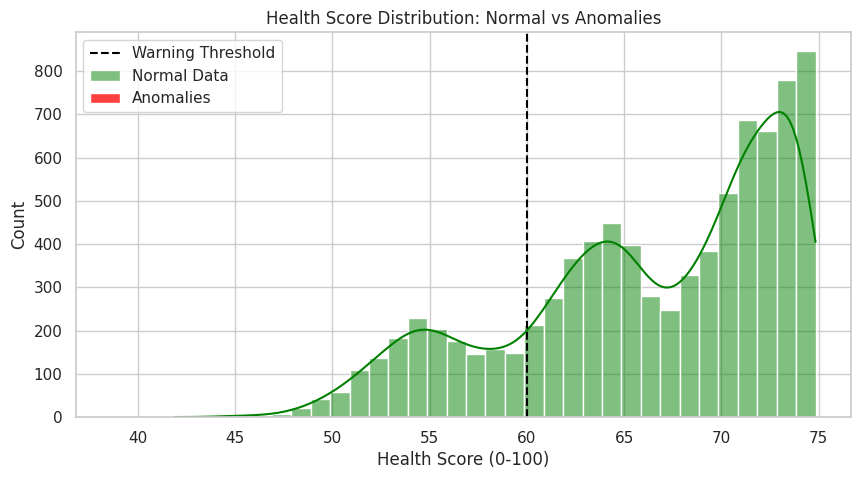


Saving model...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# --- 1. LOAD DATA ---
try:
    df = pd.read_csv('sensor_health_training_data_final.csv')
    print(f"Loaded {len(df)} rows of training data.")
except FileNotFoundError:
    print("Error: 'sensor_health_training_data.csv' not found. Please run the previous data generation step.")

# Define the exact feature list (Order matters!)
features = [
    'pzem.voltage', 'ina3221.battery.voltage', 'ina3221.battery.current_ma',
    'system.rssi', 'system.free_heap', 'system.cpu_temp', 'si7021.temperature'
]
X = df[features]

# --- 2. TRAIN MODEL ---
# Scaler: Normalizes data (e.g., converts 194000 heap and 3.3V into comparable scales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Isolation Forest
# contamination=0.01 means "Assume 1% of the training data might be noise/imperfect"
model = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
model.fit(X_scaled)

print("Model Trained Successfully!")

# --- 3. VALIDATION (The "Sabotage" Test) ---
# We create fake 'Bad' data to see if the model detects it.

sabotage_scenarios = [
    # Case 1: Overheating CPU (85C)
    [220, 8.1, -200, -70, 190000, 85.0, 30.0],
    # Case 2: Dead Battery (3.0V) while Mains OFF
    [0, 3.0, 100, -70, 190000, 45.0, 30.0],
    # Case 3: Memory Leak (Heap drops to 1000)
    [220, 8.1, -200, -70, 1000, 45.0, 30.0],
    # Case 4: Weak Signal (-95 dBm)
    [220, 8.1, -200, -95, 190000, 45.0, 30.0],
    # Case 5: "Zombie" (Mains ON but Battery Draining fast? Impossible!)
    [220, 8.0, 500, -70, 190000, 45.0, 30.0]
]

# Convert to DataFrame
bad_df = pd.DataFrame(sabotage_scenarios, columns=features)
bad_X_scaled = scaler.transform(bad_df)

# --- 4. HEALTH SCORE FUNCTION ---
def calculate_score(model, data_scaled):
    # Get raw decision function (roughly -0.5 to +0.5)
    raw_scores = model.decision_function(data_scaled)
    # Convert to 0-100 scale
    # Shift raw score so 0.0 becomes 50%, and scale up
    health_scores = 50 + (raw_scores * 100)
    # Clip between 0 and 100
    return np.clip(health_scores, 0, 100)

# Calculate scores for Normal vs Bad
normal_scores = calculate_score(model, X_scaled)
bad_scores = calculate_score(model, bad_X_scaled)

# --- 5. GENERATE REPORT ---
print("\n" + "="*40)
print("      MODEL PERFORMANCE REPORT      ")
print("="*40)

print(f"\n[ TRAINING SET (Normal Data) ]")
print(f"   - Average Health Score: {np.mean(normal_scores):.2f}%")
print(f"   - Min Health Score:     {np.min(normal_scores):.2f}%")
print(f"   - Max Health Score:     {np.max(normal_scores):.2f}%")

print(f"\n[ ANOMALY TEST (Sabotage Data) ]")
scenario_names = ["Overheating", "Dead Battery", "Memory Leak", "Weak WiFi", "Zombie Power"]
for i, score in enumerate(bad_scores):
    status = "DETECTED (Pass)" if score < 60 else "MISSED (Fail)"
    print(f"   - Scenario '{scenario_names[i]}': Score {score:.1f}% -> {status}")

# Visual Distribution
plt.figure(figsize=(10, 5))
sns.histplot(normal_scores, color='green', label='Normal Data', kde=True)
sns.histplot(bad_scores, color='red', label='Anomalies', kde=False, bins=5)
plt.axvline(x=60, color='black', linestyle='--', label='Warning Threshold')
plt.title('Health Score Distribution: Normal vs Anomalies')
plt.xlabel('Health Score (0-100)')
plt.legend()
plt.show()

# --- 6. SAVE MODEL ---
bundle = {
    "model": model,
    "scaler": scaler,
    "feature_names": features
}
with open('sensor_health_model.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print("\nSaving model...")
files.download('sensor_health_model.pkl')

In [19]:
import pandas as pd
import numpy as np
from google.colab import files

# --- 1. Load Real Data ---
try:
    real_df = pd.read_csv('new_sensor_health_data.csv')
    real_count = len(real_df)
    print(f"Detected {real_count} lines of Real Data.")
except:
    print("Real data file not found, creating dummy for demo.")
    real_count = 100
    real_df = pd.DataFrame(columns=['pzem.voltage', 'ina3221.battery.voltage', 'ina3221.battery.current_ma', 'system.rssi', 'system.free_heap', 'system.cpu_temp', 'si7021.temperature'])

# --- 2. TIGHTENED BALANCING ---
n_rows = real_count

def generate_system_noise(n):
    # CHANGE: Reduced 'scale' (noise) significantly to match real sensor stability
    return {
        'system.rssi': np.round(np.random.normal(-78, 0.5, n), 4),       # Reduced noise from 4.0 to 0.5
        'system.free_heap': np.round(np.random.normal(194056, 1, n), 4), # Reduced noise from 10 to 1 (Very Stable)
        'system.cpu_temp': np.round(np.random.normal(43.6, 0.1, n), 4),  # Reduced noise from 0.5 to 0.1
        'si7021.temperature': np.round(np.random.normal(31.7, 0.1, n), 4)# Reduced noise from 0.5 to 0.1
    }

# --- SCENARIO B: MAINS OFF (Power Outage) ---
common_noise_off = generate_system_noise(n_rows)
mains_off = {
    'pzem.voltage': np.round(np.random.uniform(0.0, 5.0, n_rows), 4),   # Reduced range to 0-5V (typical ghost voltage)
    'ina3221.battery.voltage': np.round(np.random.uniform(7.0, 8.0, n_rows), 4),
    'ina3221.battery.current_ma': np.round(np.random.normal(190.0, 2.0, n_rows), 4), # Tighter current variance
    **common_noise_off
}

df_off = pd.DataFrame(mains_off)

# --- 3. COMBINE ---
final_df = pd.concat([real_df, df_off], ignore_index=True)
final_df = final_df.sample(frac=1).reset_index(drop=True)

filename = 'balanced_training_data_tight.csv'
final_df.to_csv(filename, index=False)
print("Dataset Balanced and Tightened.")
files.download(filename)

Detected 6475 lines of Real Data.
Dataset Balanced and Tightened.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Loaded 12950 rows of training data.
Model Trained Successfully!

      MODEL PERFORMANCE REPORT      

[ TRAINING SET (Normal Data) ]
   - Average Health Score: 65.70%
   - Min Health Score:     41.55%
   - Max Health Score:     72.37%

[ ANOMALY TEST (Sabotage Data) ]
   - Scenario 'Overheating': Score 37.9% -> DETECTED (Pass)
   - Scenario 'Dead Battery': Score 40.8% -> DETECTED (Pass)
   - Scenario 'Memory Leak': Score 40.4% -> DETECTED (Pass)
   - Scenario 'Weak WiFi': Score 38.5% -> DETECTED (Pass)
   - Scenario 'Zombie Power': Score 42.0% -> DETECTED (Pass)


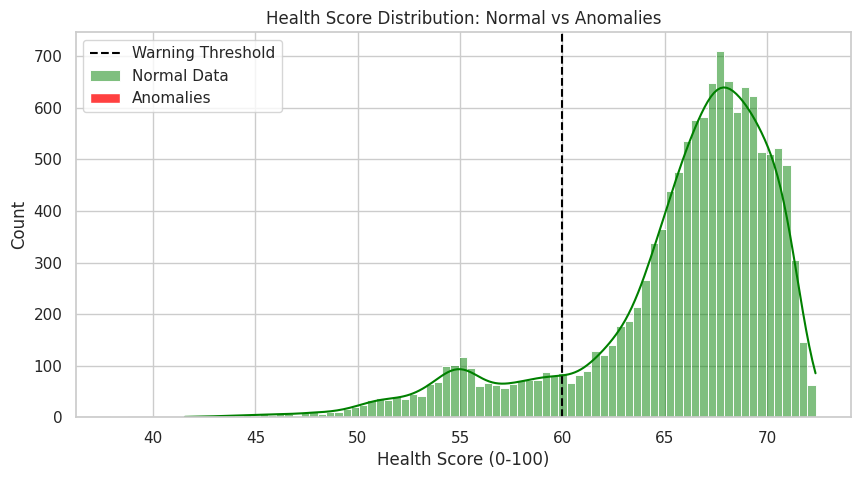


Saving model...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# --- 1. LOAD DATA ---
try:
    df = pd.read_csv('balanced_training_data_tight.csv')
    print(f"Loaded {len(df)} rows of training data.")
except FileNotFoundError:
    print("Error: 'sensor_health_training_data.csv' not found. Please run the previous data generation step.")

# Define the exact feature list (Order matters!)
features = [
    'pzem.voltage', 'ina3221.battery.voltage', 'ina3221.battery.current_ma',
    'system.rssi', 'system.free_heap', 'system.cpu_temp', 'si7021.temperature'
]
X = df[features]

# --- 2. TRAIN MODEL ---
# Scaler: Normalizes data (e.g., converts 194000 heap and 3.3V into comparable scales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Isolation Forest
# contamination=0.01 means "Assume 1% of the training data might be noise/imperfect"
model = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
model.fit(X_scaled)

print("Model Trained Successfully!")

# --- 3. VALIDATION (The "Sabotage" Test) ---
# We create fake 'Bad' data to see if the model detects it.

sabotage_scenarios = [
    # Case 1: Overheating CPU (85C)
    [220, 8.1, -200, -70, 190000, 85.0, 30.0],
    # Case 2: Dead Battery (3.0V) while Mains OFF
    [0, 3.0, 100, -70, 190000, 45.0, 30.0],
    # Case 3: Memory Leak (Heap drops to 1000)
    [220, 8.1, -200, -70, 1000, 45.0, 30.0],
    # Case 4: Weak Signal (-95 dBm)
    [220, 8.1, -200, -95, 190000, 45.0, 30.0],
    # Case 5: "Zombie" (Mains ON but Battery Draining fast? Impossible!)
    [220, 8.0, 500, -70, 190000, 45.0, 30.0]
]

# Convert to DataFrame
bad_df = pd.DataFrame(sabotage_scenarios, columns=features)
bad_X_scaled = scaler.transform(bad_df)

# --- 4. HEALTH SCORE FUNCTION ---
def calculate_score(model, data_scaled):
    # Get raw decision function (roughly -0.5 to +0.5)
    raw_scores = model.decision_function(data_scaled)
    # Convert to 0-100 scale
    # Shift raw score so 0.0 becomes 50%, and scale up
    health_scores = 50 + (raw_scores * 100)
    # Clip between 0 and 100
    return np.clip(health_scores, 0, 100)

# Calculate scores for Normal vs Bad
normal_scores = calculate_score(model, X_scaled)
bad_scores = calculate_score(model, bad_X_scaled)

# --- 5. GENERATE REPORT ---
print("\n" + "="*40)
print("      MODEL PERFORMANCE REPORT      ")
print("="*40)

print(f"\n[ TRAINING SET (Normal Data) ]")
print(f"   - Average Health Score: {np.mean(normal_scores):.2f}%")
print(f"   - Min Health Score:     {np.min(normal_scores):.2f}%")
print(f"   - Max Health Score:     {np.max(normal_scores):.2f}%")

print(f"\n[ ANOMALY TEST (Sabotage Data) ]")
scenario_names = ["Overheating", "Dead Battery", "Memory Leak", "Weak WiFi", "Zombie Power"]
for i, score in enumerate(bad_scores):
    status = "DETECTED (Pass)" if score < 60 else "MISSED (Fail)"
    print(f"   - Scenario '{scenario_names[i]}': Score {score:.1f}% -> {status}")

# Visual Distribution
plt.figure(figsize=(10, 5))
sns.histplot(normal_scores, color='green', label='Normal Data', kde=True)
sns.histplot(bad_scores, color='red', label='Anomalies', kde=False, bins=5)
plt.axvline(x=60, color='black', linestyle='--', label='Warning Threshold')
plt.title('Health Score Distribution: Normal vs Anomalies')
plt.xlabel('Health Score (0-100)')
plt.legend()
plt.show()

# --- 6. SAVE MODEL ---
bundle = {
    "model": model,
    "scaler": scaler,
    "feature_names": features
}
with open('sensor_health_model.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print("\nSaving model...")
files.download('sensor_health_model.pkl')

Loaded 12950 rows of training data.
Model Trained Successfully!

      MODEL PERFORMANCE REPORT      

[ TRAINING SET (Normal Data) ]
   - Average Health Score: 71.34%
   - Min Health Score:     47.19%
   - Max Health Score:     78.01%

[ ANOMALY TEST (Sabotage Data) ]
   - Scenario 'Overheating': Score 43.6% -> DETECTED (Pass)
   - Scenario 'Dead Battery': Score 46.5% -> DETECTED (Pass)
   - Scenario 'Memory Leak': Score 46.0% -> DETECTED (Pass)
   - Scenario 'Weak WiFi': Score 44.1% -> DETECTED (Pass)
   - Scenario 'Zombie Power': Score 47.6% -> DETECTED (Pass)


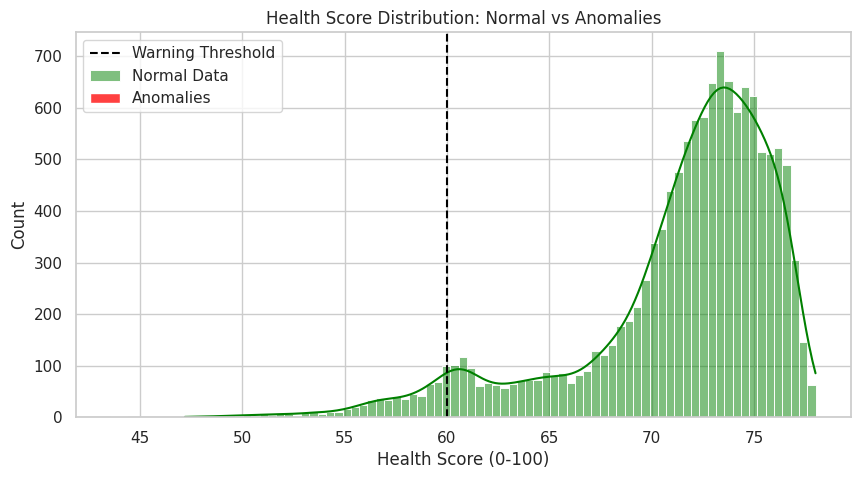


Saving model...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# --- 1. LOAD DATA ---
try:
    df = pd.read_csv('balanced_training_data_tight.csv')
    print(f"Loaded {len(df)} rows of training data.")
except FileNotFoundError:
    print("Error: 'sensor_health_training_data.csv' not found. Please run the previous data generation step.")

# Define the exact feature list (Order matters!)
features = [
    'pzem.voltage', 'ina3221.battery.voltage', 'ina3221.battery.current_ma',
    'system.rssi', 'system.free_heap', 'system.cpu_temp', 'si7021.temperature'
]
X = df[features]

# --- 2. TRAIN MODEL ---
# Scaler: Normalizes data (e.g., converts 194000 heap and 3.3V into comparable scales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Isolation Forest
# contamination=0.01 means "Assume 1% of the training data might be noise/imperfect"
model = IsolationForest(n_estimators=200, contamination=0.001, random_state=42)
model.fit(X_scaled)

print("Model Trained Successfully!")

# --- 3. VALIDATION (The "Sabotage" Test) ---
# We create fake 'Bad' data to see if the model detects it.

sabotage_scenarios = [
    # Case 1: Overheating CPU (85C)
    [220, 8.1, -200, -70, 190000, 85.0, 30.0],
    # Case 2: Dead Battery (3.0V) while Mains OFF
    [0, 3.0, 100, -70, 190000, 45.0, 30.0],
    # Case 3: Memory Leak (Heap drops to 1000)
    [220, 8.1, -200, -70, 1000, 45.0, 30.0],
    # Case 4: Weak Signal (-95 dBm)
    [220, 8.1, -200, -95, 190000, 45.0, 30.0],
    # Case 5: "Zombie" (Mains ON but Battery Draining fast? Impossible!)
    [220, 8.0, 500, -70, 190000, 45.0, 30.0]
]

# Convert to DataFrame
bad_df = pd.DataFrame(sabotage_scenarios, columns=features)
bad_X_scaled = scaler.transform(bad_df)

# --- 4. HEALTH SCORE FUNCTION ---
def calculate_score(model, data_scaled):
    # Get raw decision function (roughly -0.5 to +0.5)
    raw_scores = model.decision_function(data_scaled)
    # Convert to 0-100 scale
    # Shift raw score so 0.0 becomes 50%, and scale up
    health_scores = 50 + (raw_scores * 100)
    # Clip between 0 and 100
    return np.clip(health_scores, 0, 100)

# Calculate scores for Normal vs Bad
normal_scores = calculate_score(model, X_scaled)
bad_scores = calculate_score(model, bad_X_scaled)

# --- 5. GENERATE REPORT ---
print("\n" + "="*40)
print("      MODEL PERFORMANCE REPORT      ")
print("="*40)

print(f"\n[ TRAINING SET (Normal Data) ]")
print(f"   - Average Health Score: {np.mean(normal_scores):.2f}%")
print(f"   - Min Health Score:     {np.min(normal_scores):.2f}%")
print(f"   - Max Health Score:     {np.max(normal_scores):.2f}%")

print(f"\n[ ANOMALY TEST (Sabotage Data) ]")
scenario_names = ["Overheating", "Dead Battery", "Memory Leak", "Weak WiFi", "Zombie Power"]
for i, score in enumerate(bad_scores):
    status = "DETECTED (Pass)" if score < 60 else "MISSED (Fail)"
    print(f"   - Scenario '{scenario_names[i]}': Score {score:.1f}% -> {status}")

# Visual Distribution
plt.figure(figsize=(10, 5))
sns.histplot(normal_scores, color='green', label='Normal Data', kde=True)
sns.histplot(bad_scores, color='red', label='Anomalies', kde=False, bins=5)
plt.axvline(x=60, color='black', linestyle='--', label='Warning Threshold')
plt.title('Health Score Distribution: Normal vs Anomalies')
plt.xlabel('Health Score (0-100)')
plt.legend()
plt.show()

# --- 6. SAVE MODEL ---
bundle = {
    "model": model,
    "scaler": scaler,
    "feature_names": features
}
with open('sensor_health_model.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print("\nSaving model...")
files.download('sensor_health_model.pkl')